In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import json
import string
import Basic_functions as bf  #Homemade script.
import time
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colormaps

from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import roc_auc_score, roc_curve, log_loss, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

from scipy import sparse

import optuna

###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"txt_files\\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

print('Packages loaded')

Packages loaded


<h1> Importing the files.</h1>
for 36000 files, takes roughly 7 minuttes

In [3]:
def import_speech_files_to_array(folder_path):
    txt_files_content = []
    Files_read = 0
    folder_read = 0
    
    for i in folder_path:
        for filename in os.listdir(i): #folder_path):
            if filename.endswith('.txt'):
                Files_read = Files_read + 1
                file_path = os.path.join(i, filename) #folder_path, filename)
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        
                        content = file.read()
                        
                        # Split at the first occurrence of "\n\n\n" and take the part after it
                        parts = content.split('\n\n', 1)
                        if len(parts) > 1:
                            text_after_marker = parts[1]
                        else:
                            text_after_marker = content  # Fallback if "\n\n\n" not found
    

                        # Replace escaped newlines (\\n) with spaces, then remove all newlines
                        text_after_marker = text_after_marker.replace('\\n', ' ').replace('\n', ' ')
    
                        # Convert to lowercase, keep letters (including æøå), spaces, and remove ellipses
                        cleaned_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', text_after_marker.lower())
                        cleaned_text = cleaned_text.replace("'", "")
                        cleaned_text = cleaned_text.replace('...', '')  # Remove ellipses
    
                        # Remove extra spaces (e.g., multiple spaces)
                        cleaned_text = ' '.join(cleaned_text.split())
    
                        txt_files_content.append(cleaned_text)
                        
                        print(f'Folders read: {folder_read}, files read: {Files_read}', end = '\r')
                        
                except Exception as e:
                    print(f"Error reading {filename}: {e}")

                
    print('\n','Files read:', Files_read)

    return  (pd.DataFrame(txt_files_content, columns = ['text'])
            )


In [2]:
df_speech

NameError: name 'df_speech' is not defined

In [12]:
df_full = pd.concat([df_speech, df], join="inner", ignore_index=True)
df_full

,text,year,sermon,LIX,topic,text_type
0,landsmænd og danske studenter sit fædreland sk...,1942.185845,0,41.674749,nan,0
1,der er noget udpræget centralt over dette skøn...,1945.355251,1,36.583556,nan,0
2,syndsforladelsens naade med fortællingen om je...,1944.721461,1,55.123771,nan,0
3,disse ord indeholder en herlig forjættelse som...,1945.412785,1,31.591425,nan,0
4,ti gode livsråd du er grønlands fremtid men du...,2025.557534,0,23.361107,nan,0
...,...,...,...,...,...,...
857807,europæisk klimakorrespondent et lille blåt kli...,2009.9358447488585,0,50.0,Kultur,1
857808,journalist alle fire personer om bord på et am...,2010.6627853881278,0,45.95238095238095,Internationalt,1
857809,opfindsomheden hos medierne er stor når det ha...,2010.3360730593606,0,35.69444444444444,Kultur,1
857810,sofaspil sæt dit eget vmhold og vind flotte pr...,2010.527397260274,0,42.333333333333336,Danmark,1


<h1> Preprocessing the files</h1>
takes roughly 192.493180 seconds

In [2]:
def preprocess(text, min_word_length=3, max_word_length=30):
    
    stemmer = SnowballStemmer(language='danish')
    
    tokens = word_tokenize(text, language = 'danish', preserve_line=False)

    tokens = [
        word for word in tokens
        if (word.isalpha() and
            word not in string.punctuation and
            min_word_length <= len(word) <= max_word_length)
    ]
    
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

####################################

start = time.time()

df_clean = pd.DataFrame({
    'text': df_full['text'].apply(preprocess),
    'length': df_full['text'].str.len(),
    'LIX': df_full['LIX'].astype(float),
    'topic': df_full['topic'],
    'text_type': df_full['text_type'],
    'year': df_full['year'].astype(float)
})
    
stop = time.time()

print(f'Time preprocessing: {(stop-start)/60:3f} minuttes')


KeyboardInterrupt



In [15]:
df_clean

,text,length,LIX,topic,text_type,year
0,landsmænd dansk student fædreland skyld udret ...,12760,41.674749,nan,0,1942.185845
1,udpræg centralt skøn evangelium kristus saml f...,4920,36.583556,nan,0,1945.355251
2,syndsforlad naad fortælling jesu mød synderind...,6735,55.123771,nan,0,1944.721461
3,ord indehold her forjæt jesus gav discipl foru...,4106,31.591425,nan,0,1945.412785
4,god livsråd grønland fremtid bær ansvar ældr g...,2380,23.361107,nan,0,2025.557534
...,...,...,...,...,...,...
857807,europæisk klimakorrespondent blåt klistermærk ...,216,50.000000,Kultur,1,2009.935845
857808,journalist person bord amerikansk militærfly d...,217,45.952381,Internationalt,1,2010.662785
857809,opfindsom medi handl driv gæk lyt seer april f...,244,35.694444,Kultur,1,2010.336073
857810,sofaspil sæt eget vmhold vind flot præmi,51,42.333333,Danmark,1,2010.527397


In [18]:
print(df_clean['text'], '\n\n')
print(df['text'])

0         landsmænd dansk student fædreland skyld udret ...
1         udpræg centralt skøn evangelium kristus saml f...
2         syndsforlad naad fortælling jesu mød synderind...
3         ord indehold her forjæt jesus gav discipl foru...
4         god livsråd grønland fremtid bær ansvar ældr g...
                                ...                        
857807    europæisk klimakorrespondent blåt klistermærk ...
857808    journalist person bord amerikansk militærfly d...
857809    opfindsom medi handl driv gæk lyt seer april f...
857810             sofaspil sæt eget vmhold vind flot præmi
857811    kulturjournalist danmark final europæisk melod...
Name: text, Length: 857812, dtype: object 


0                                                          
1                                                          
2                                                          
3                                                          
4                                                      

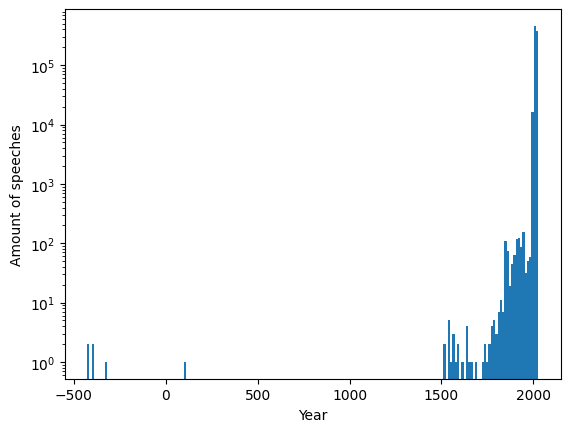

In [20]:
plt.hist(df_clean['year'], bins = 200)
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Amount of speeches')
plt.show()

<h1> Load prepared data</h1>

In [3]:
df_clean = pd.read_csv('NLTK_clean_all.csv', 
                       na_values=['', 'nan', 'NAN'],
                        sep = ";",
                        encoding='utf-8',
                        )
df_clean['text'] = df_clean['text'].fillna('')
df_clean['text'] = df_clean['text'].astype(str)
df_clean = df_clean[df_clean['text'].str.strip().astype('bool')]

In [15]:
random_sample = df_clean.loc[0:10000].sample(n=100)
np.unique(random_sample['text_type'].values, return_counts= True)

(array([0, 1]), array([65, 35]))

In [89]:
filter_art = (df_clean['text_type'].values == 1)
filter_spe = (df_clean['text_type'].values == 0)
print(filter_art)

len_tokens = [len(w) for w in df_clean['text'][filter_art]]
print(f'Texts type length: {np.mean(len_tokens):1f} +- {np.std(len_tokens):1f} words')



[False False False ...  True  True  True]
Texts type length: 491.022212 +- 771.740514 words


In [91]:
df_clean.dtypes

text          object
length         int64
LIX          float64
topic         object
text_type      int64
year         float64
dtype: object

<h1> Embedding the data</h1>
TF_IDF turns the words into a sparse matrix, weighing the words. Biased by text length, though.

In [93]:
from scipy.sparse import hstack, csr_matrix


vectorizer = TfidfVectorizer(use_idf=True, min_df=25, max_df=0.8, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
#Term Frequency-Inverse Document Frequency)

#X_lix = csr_matrix(df_clean[['LIX']].astype(float).values)
#X_len = csr_matrix(df_clean[['length']].astype(float).values)
X_text = (vectorizer.fit_transform(df_clean['text'])).astype(np.float32)

X = X_text #hstack([X_text, X_lix, X_len]) #,X_sermon])
y = df_clean['text_type']
print(f"Sparsity: {X_text.nnz / np.prod(X_text.shape):.3f}")
print("TF-IDF matrix shape:", X.shape)

Sparsity: 0.001
TF-IDF matrix shape: (780044, 64478)


In [21]:
vectorizer.get_feature_names_out()

array(['aaa', 'aab', 'aabanfør', ..., 'øye', 'øystein', 'øyvind'],
      dtype=object)

In [32]:
X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 3328811 stored elements and shape (54753, 14418)>

<h1> Dimensionality reduction</h1>

In [23]:
svd = TruncatedSVD(n_components=2,
             algorithm='randomized',
             n_iter=10,
             n_oversamples=100,
             power_iteration_normalizer='auto',
             random_state=42,
             tol=0.0)

start = time.time()

X_LSA = svd.fit_transform(X)
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

stop = time.time()
print(f'Done in {stop-start:3f} seconds', '\n')

[0.00460179 0.00635444]
0.010956227
[93.954384 73.460266]
Done in 85.870628 seconds 



In [101]:
step = 3
intervals = np.arange(2000,2030,step)
intervals[-1] = 2026
print(len(intervals))

try:
    # Create cutoffs column
    df_clean['cutoffs'] = pd.cut(
        df_clean['year'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(10, 5), )
    final_cut = df_clean['cutoffs'].cat.categories[-1]
    colors = cm.jet(np.linspace(0, 1, len(df_clean['cutoffs'].cat.categories)))

    plt.scatter(
        X_LSA[df_clean['cutoffs'] == final_cut, 0],
        X_LSA[df_clean['cutoffs'] == final_cut, 1],
        marker='.',
        label=f'{str(final_cut)} - {str(2026)}',
        alpha=1,
        color= 'black'#colors[-1]  # Last color in the jet colormap
    )

    for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
        subX_LSA = X_LSA[df_clean['cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker='.',
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=0.3,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Speeches', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [1,2,3,4,5,6,7,8,0]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

10
Error occurred: boolean index did not match indexed array along axis 0; size of axis is 857812 but size of corresponding boolean axis is 780044

Debugging info:
DataFrame columns: ['text', 'length', 'LIX', 'topic', 'text_type', 'year', 'cutoffs']
DataFrame shape: (780044, 7)
Sample of year values: 0    1942.185845
1    1945.355251
2    1944.721461
3    1945.412785
4    2025.557534
Name: year, dtype: float64


<Figure size 1000x500 with 0 Axes>

In [103]:
step = 10
intervals = np.arange(10,80,step)
print(len(intervals))

try:
    # Create cutoffs column
    df_clean['LIX_cutoffs'] = pd.cut(
        df_clean['LIX'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'LIX_cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(10, 5), )
    colors = cm.jet(np.linspace(0, 1, len(df_clean['LIX_cutoffs'].cat.categories)))

    for i, cutoff in enumerate(df_clean['LIX_cutoffs'].cat.categories[:]):
        subX_LSA = X_LSA[df_clean['LIX_cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker='.',
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=0.2,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Speeches', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [0,1,2,3,4,5]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

7
Error occurred: boolean index did not match indexed array along axis 0; size of axis is 857812 but size of corresponding boolean axis is 780044

Debugging info:
DataFrame columns: ['text', 'length', 'LIX', 'topic', 'text_type', 'year', 'cutoffs', 'LIX_cutoffs']
DataFrame shape: (780044, 8)
Sample of year values: 0    1942.185845
1    1945.355251
2    1944.721461
3    1945.412785
4    2025.557534
Name: year, dtype: float64


<Figure size 1000x500 with 0 Axes>

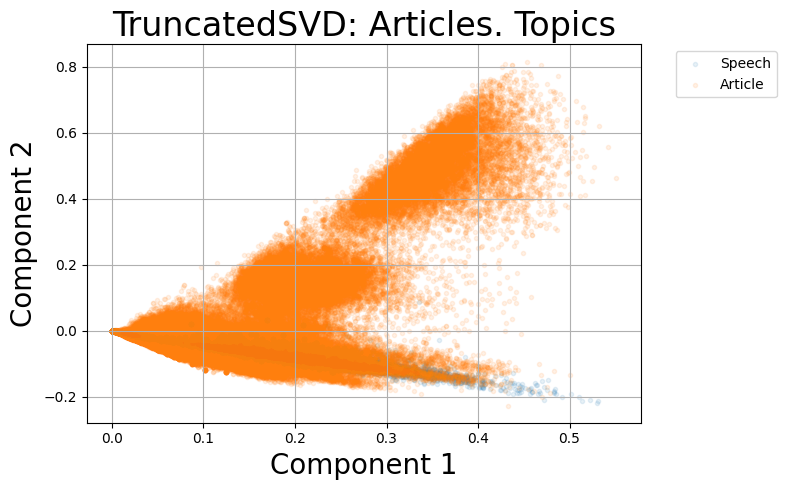

In [29]:
plt.figure(figsize=(8, 5))
for i in range(2):
    plt.scatter(X_LSA[df_clean['text_type'].values == i,0], X_LSA[df_clean['text_type'].values == i,1], marker = '.', alpha = 0.1, label = i)
#plt.scatter(X_LSA[ is_serm == 0,0], X_LSA[is_serm == 0,1], marker = '.', label = 'Speech')
#plt.scatter(X_LSA[:,0], X_LSA[:,1],marker = '.', c = df_sermon.values, alpha=1)
plt.title('TruncatedSVD: Articles. Topics', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', labels = ['Speech', 'Article'])
#plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

<h2> </h2>

In [44]:
import umap

reducer = umap.UMAP(n_neighbors= 5, min_dist= 1.0)

embedding = reducer.fit_transform(X)


KeyboardInterrupt



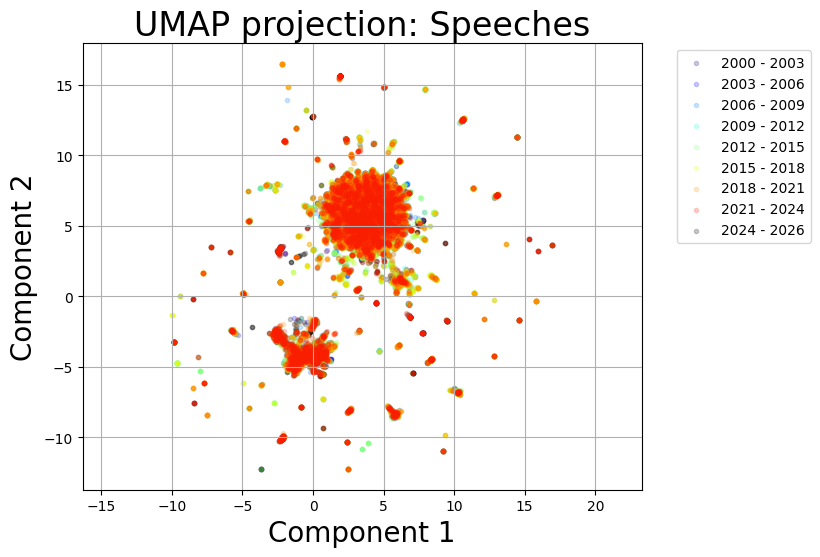

In [86]:
plt.figure(figsize = (8,5))
final_cut = df_clean['cutoffs'].cat.categories[-1]
colors = cm.jet(np.linspace(0, 1, len(df_clean['cutoffs'].cat.categories)))

step = 3

plt.scatter(
        embedding[df_clean['cutoffs'] == final_cut, 0],
        embedding[df_clean['cutoffs'] == final_cut, 1],
        marker='.',
        label=f'{str(final_cut)} - {str(2026)}',
        alpha=0.2,
        color='black' #colors[-1]  # Last color in the jet colormap
    )

for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
    subembedding = embedding[df_clean['cutoffs'] == cutoff, :]
    plt.scatter(
        subembedding[:,0],
        subembedding[:,1],
        marker='.',
        label=f'{str(cutoff)} - {str(cutoff + step)}',
        alpha=0.2,
        color=colors[i]  # Use corresponding color from the colormap
    )

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,2,3,4,5,6,7,8,0]

plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection: Speeches', fontsize=24);
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.grid()
plt.show()

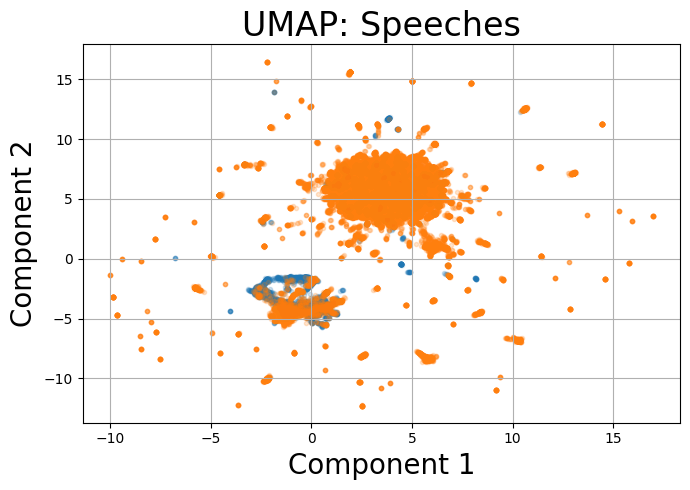

In [92]:
plt.figure(figsize=(7, 5))
for i in range(2):
    plt.scatter(embedding[df_clean['text_type'].values == i,0],
                embedding[df_clean['text_type'].values == i,1], 
                marker = '.', label = [df_clean['text_type'].values == i], alpha = 0.2)
    
plt.title('UMAP: Speeches', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
#plt.scatter(embedding[:,0], embedding[:,1], c = df_labels['sermon'].values)

<h1>XGboost model training</h1>

In [35]:
# svd = TruncatedSVD(n_components=1000,
#             algorithm='randomized',
#             n_iter=20,
#             n_oversamples=200,
#             power_iteration_normalizer='auto',
#             random_state=42,
#             tol=0.0)
#X_reduced = svd.fit_transform(X)

#reducerUmap = umap.UMAP(n_components = 250, n_neighbors= 30, min_dist= 0.0)

#X_reduced = reducerUmap.fit_transform(X)

svd = TruncatedSVD(n_components=100,
             algorithm='randomized',
             n_iter=5,
             n_oversamples=10,
             power_iteration_normalizer='auto',
             random_state=42,
             )

X_LSA = svd.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X_LSA, y, test_size=0.20, random_state=42, stratify = y)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print('Done')

Done


In [43]:
y_train.values

array([1, 1, 1, ..., 1, 1, 1])

<h1>Optuna</h1>

In [111]:
import xgboost as xgb
from sklearn.metrics import log_loss, precision_score
print('running xgboost version:', xgb.__version__)

scale_pos_weight = len(y_train[y_train.values == 0]) / len(y_train[y_train.values == 1])

evalset = [(X_train, y_train), (X_eval, y_eval)]

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    learning_rate = trial.suggest_float("learning_rate", 0.20, 0.30)
    max_depth = trial.suggest_int("max_depth", 3, 15, log=True)
    reg_alpha = trial.suggest_float("reg_alpha", 0.5, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0.5, 1)
    #gamma = trial.suggest_float("gamma", 0.50, 1),
    #min_child_weight = trial.suggest_float("min_child_weight", 1.0, 5.0),
    subsample = trial.suggest_float("subsample", 0.50, 0.99)

    model = xgb.XGBClassifier(objective='binary:logistic',
                         scale_pos_weight=scale_pos_weight,
                         eval_metric = 'logloss',
                         importance_type="weight",
                         n_estimators=n_estimators,
                         learning_rate=learning_rate,
                         max_depth = max_depth,
                         reg_alpha = reg_alpha,
                         reg_lambda = reg_lambda,
                         #min_child_weight = min_child_weight,
                         #gamma = gamma,
                         subsample = subsample,
                         n_jobs = 1,
                         tree_method = 'hist',
                         early_stopping_rounds = 40,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)
    
    model.fit(X_train, y_train, eval_set= evalset, verbose=2)
    y_pred = model.predict_proba(X_train)
    logloss = log_loss(y_train, y_pred)
    return(logloss)


#################################################
study_name = "NLTK-study"
#storage_name = f"sqlite:///{study_name}.db"
optuna.delete_study(study_name=study_name, storage=storage_name)
study = optuna.create_study(study_name = study_name, storage = storage_name, load_if_exists=True, direction="minimize")
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

running xgboost version: 3.0.0


[I 2026-06-05 12:08:39,230] A new study created in RDB with name: NLTK-study


[0]	validation_0-logloss:0.49373	validation_1-logloss:0.49400
[2]	validation_0-logloss:0.29859	validation_1-logloss:0.29966
[4]	validation_0-logloss:0.20500	validation_1-logloss:0.20617
[6]	validation_0-logloss:0.15294	validation_1-logloss:0.15444
[8]	validation_0-logloss:0.12100	validation_1-logloss:0.12234
[10]	validation_0-logloss:0.10023	validation_1-logloss:0.10173
[12]	validation_0-logloss:0.08544	validation_1-logloss:0.08719
[14]	validation_0-logloss:0.07434	validation_1-logloss:0.07616
[16]	validation_0-logloss:0.06671	validation_1-logloss:0.06861
[18]	validation_0-logloss:0.06014	validation_1-logloss:0.06208
[20]	validation_0-logloss:0.05532	validation_1-logloss:0.05717
[22]	validation_0-logloss:0.05169	validation_1-logloss:0.05360
[24]	validation_0-logloss:0.04816	validation_1-logloss:0.05007
[26]	validation_0-logloss:0.04580	validation_1-logloss:0.04770
[28]	validation_0-logloss:0.04323	validation_1-logloss:0.04513
[30]	validation_0-logloss:0.04115	validation_1-logloss:0.043

[I 2026-06-05 12:10:40,358] Trial 0 finished with value: 0.014048138781215837 and parameters: {'n_estimators': 170, 'learning_rate': 0.2848510151416892, 'max_depth': 7, 'reg_alpha': 0.7407898756728948, 'reg_lambda': 0.6830732610981451, 'subsample': 0.7132081862005469}. Best is trial 0 with value: 0.014048138781215837.


[0]	validation_0-logloss:0.49249	validation_1-logloss:0.49310
[2]	validation_0-logloss:0.29700	validation_1-logloss:0.29852
[4]	validation_0-logloss:0.20302	validation_1-logloss:0.20501
[6]	validation_0-logloss:0.15005	validation_1-logloss:0.15213
[8]	validation_0-logloss:0.11822	validation_1-logloss:0.12021
[10]	validation_0-logloss:0.09714	validation_1-logloss:0.09889
[12]	validation_0-logloss:0.08316	validation_1-logloss:0.08480
[14]	validation_0-logloss:0.07300	validation_1-logloss:0.07462
[16]	validation_0-logloss:0.06562	validation_1-logloss:0.06741
[18]	validation_0-logloss:0.05968	validation_1-logloss:0.06151
[20]	validation_0-logloss:0.05508	validation_1-logloss:0.05683
[22]	validation_0-logloss:0.05122	validation_1-logloss:0.05304
[24]	validation_0-logloss:0.04795	validation_1-logloss:0.04983
[26]	validation_0-logloss:0.04519	validation_1-logloss:0.04706
[28]	validation_0-logloss:0.04247	validation_1-logloss:0.04442
[30]	validation_0-logloss:0.04041	validation_1-logloss:0.042

...

[0]	validation_0-logloss:0.54621	validation_1-logloss:0.54644
[2]	validation_0-logloss:0.37119	validation_1-logloss:0.37204
[4]	validation_0-logloss:0.27141	validation_1-logloss:0.27263
[6]	validation_0-logloss:0.20894	validation_1-logloss:0.21048
[8]	validation_0-logloss:0.16867	validation_1-logloss:0.17026
[10]	validation_0-logloss:0.13966	validation_1-logloss:0.14145
[12]	validation_0-logloss:0.11866	validation_1-logloss:0.12040
[14]	validation_0-logloss:0.10473	validation_1-logloss:0.10646
[16]	validation_0-logloss:0.09229	validation_1-logloss:0.09414
[18]	validation_0-logloss:0.08313	validation_1-logloss:0.08483
[20]	validation_0-logloss:0.07655	validation_1-logloss:0.07838
[22]	validation_0-logloss:0.07091	validation_1-logloss:0.07291
[24]	validation_0-logloss:0.06572	validation_1-logloss:0.06759
[26]	validation_0-logloss:0.06209	validation_1-logloss:0.06399
[28]	validation_0-logloss:0.05853	validation_1-logloss:0.06045
[30]	validation_0-logloss:0.05544	validation_1-logloss:0.057

[I 2026-06-05 12:25:24,729] Trial 8 finished with value: 0.020198314066501744 and parameters: {'n_estimators': 129, 'learning_rate': 0.2014770690162183, 'max_depth': 7, 'reg_alpha': 0.8595993448049484, 'reg_lambda': 0.9944274022580042, 'subsample': 0.7692150193211387}. Best is trial 3 with value: 0.01139913362524927.


[0]	validation_0-logloss:0.55091	validation_1-logloss:0.55109
[2]	validation_0-logloss:0.39003	validation_1-logloss:0.39111
[4]	validation_0-logloss:0.30810	validation_1-logloss:0.30941
[6]	validation_0-logloss:0.25268	validation_1-logloss:0.25384
[8]	validation_0-logloss:0.21682	validation_1-logloss:0.21798
[10]	validation_0-logloss:0.19191	validation_1-logloss:0.19273
[12]	validation_0-logloss:0.17528	validation_1-logloss:0.17612
[14]	validation_0-logloss:0.15937	validation_1-logloss:0.16027
[16]	validation_0-logloss:0.14744	validation_1-logloss:0.14859
[18]	validation_0-logloss:0.13788	validation_1-logloss:0.13897
[20]	validation_0-logloss:0.12980	validation_1-logloss:0.13109
[22]	validation_0-logloss:0.12200	validation_1-logloss:0.12343
[24]	validation_0-logloss:0.11750	validation_1-logloss:0.11900
[26]	validation_0-logloss:0.11172	validation_1-logloss:0.11325
[28]	validation_0-logloss:0.10779	validation_1-logloss:0.10920
[30]	validation_0-logloss:0.10183	validation_1-logloss:0.103

[I 2026-06-05 12:27:44,683] Trial 9 finished with value: 0.029239821134803577 and parameters: {'n_estimators': 255, 'learning_rate': 0.2376137100996104, 'max_depth': 3, 'reg_alpha': 0.8781292589006848, 'reg_lambda': 0.9777290251042878, 'subsample': 0.6436728655406887}. Best is trial 3 with value: 0.01139913362524927.


Best hyperparameters: {'n_estimators': 161, 'learning_rate': 0.2317675738344313, 'max_depth': 9, 'reg_alpha': 0.5540173203476364, 'reg_lambda': 0.5344191487023402, 'subsample': 0.9218561392599176}
Best accuracy: 0.01139913362524927


Best hyperparameters: {'n_estimators': 161, 'learning_rate': 0.2317675738344313, 'max_depth': 9, 'reg_alpha': 0.5540173203476364, 'reg_lambda': 0.5344191487023402, 'subsample': 0.9218561392599176}
Best accuracy: 0.01139913362524927

In [130]:
import xgboost as xgb
from sklearn.metrics import log_loss, precision_score
print('running xgboost version:', xgb.__version__)


model = xgb.XGBClassifier(objective='binary:logistic',
                         eval_metric = 'logloss',
                         importance_type="weight",
                         scale_pos_weight=scale_pos_weight,
                         n_estimators=161,
                         learning_rate=0.3,
                         max_depth = 9,
                         reg_alpha = 0.55,
                         reg_lambda = 0.53,
                         #gamma = 0.80
                         subsample = 0.92,
                         n_jobs = 1,
                         tree_method = 'hist',
                         #min_child_weight = 3,
                         early_stopping_rounds = 40,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)


start = time.time()

evalset = [(X_train, y_train), (X_eval, y_eval)]

model.fit(X_train, y_train, eval_set= evalset, verbose=2)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict_proba(X_eval)

logloss = log_loss(y_eval, y_pred)
#pr_score = precision_score(y_eval, y_pred)

print(f'logloss: {logloss:.3f}')
#print(f'Precision score: {pr_score:.3f}')

running xgboost version: 3.0.0
[0]	validation_0-logloss:0.47699	validation_1-logloss:0.47761
[2]	validation_0-logloss:0.27272	validation_1-logloss:0.27407
[4]	validation_0-logloss:0.17762	validation_1-logloss:0.17936
[6]	validation_0-logloss:0.12652	validation_1-logloss:0.12858
[8]	validation_0-logloss:0.09699	validation_1-logloss:0.09907
[10]	validation_0-logloss:0.07747	validation_1-logloss:0.07949
[12]	validation_0-logloss:0.06486	validation_1-logloss:0.06695
[14]	validation_0-logloss:0.05622	validation_1-logloss:0.05834
[16]	validation_0-logloss:0.04972	validation_1-logloss:0.05165
[18]	validation_0-logloss:0.04446	validation_1-logloss:0.04647
[20]	validation_0-logloss:0.04070	validation_1-logloss:0.04280
[22]	validation_0-logloss:0.03752	validation_1-logloss:0.03968
[24]	validation_0-logloss:0.03469	validation_1-logloss:0.03687
[26]	validation_0-logloss:0.03255	validation_1-logloss:0.03475
[28]	validation_0-logloss:0.03059	validation_1-logloss:0.03285
[30]	validation_0-logloss:0.0

In [132]:
from sklearn.metrics import accuracy_score
y_pred_test = model.predict_proba(X_test)
y_pred_bin = model.predict(X_test)

logloss = log_loss(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_bin)
#pr_score = precision_score(y_test, y_pred_test)

print(f'logloss: {logloss:.3f}')
print(f'Accuracy: {accuracy:.3f}')
#print(f'Precision score: {pr_score:.3f}')

logloss: 0.013
Accuracy: 0.996


In [51]:
model.save_model('model_all_bdt.json')

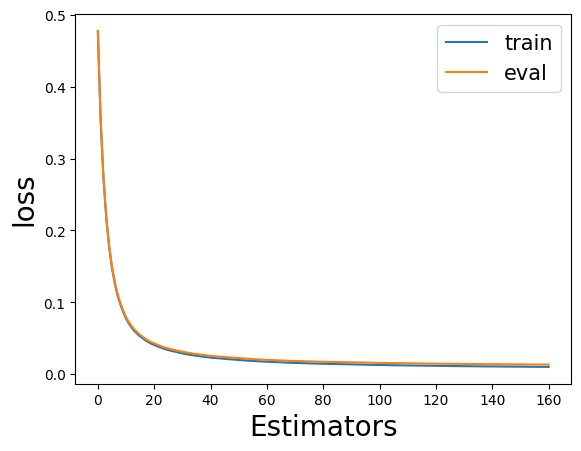

In [198]:
# retrieve performance metrics
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='eval')
# show the legend
plt.legend(  fontsize = 15)
plt.xlabel('Estimators',  fontsize = 20)
plt.ylabel('loss', fontsize = 20)
# show the plot
plt.show()

In [136]:
# Retrieve the "gain" feature importance scores
importance_scores = model.feature_importances_

# Print the feature importance scores along with feature names
Importance_labels = np.argsort(importance_scores)[-100:]
#Importance_labels = Importance_labels[ (Importance_labels != 7328) & (Importance_labels != 7327)]
print(vectorizer.get_feature_names_out()[Importance_labels])
#print(importance_scores[Importance_labels])
#for feature, score in zip(vectorizer.get_feature_names_out(), importance_scores):
#    print(f"{feature}: {score}")
print(len(Importance_labels))

['aaby' 'aarhusian' 'abdeslam' 'aabangrib' 'aaron' 'aarhusområd' 'aabned'
 'aaen' 'aark' 'aalbæk' 'abderrahman' 'aarslef' 'aalborgspil' 'abdi'
 'aakeson' 'aand' 'abb' 'aarhusiansk' 'aamand' 'aasiaat' 'aarø' 'aakti'
 'aalborgensisk' 'aabybro' 'aaskov' 'abdallah' 'aastrup' 'aarhundred'
 'abdolhamid' 'abdul' 'aarstid' 'abdulaziz' 'abdiaziz' 'aas' 'abdulla'
 'aarestrup' 'aabforsvar' 'abbot' 'ababa' 'aagaard' 'aarsland' 'abd'
 'aasted' 'abba' 'abby' 'aabn' 'abdikation' 'aarhusklub' 'aach' 'aarsag'
 'aabo' 'aalborg' 'aabspil' 'aabenbart' 'abdalla' 'aakirkeby' 'aau'
 'aabech' 'aabhold' 'abdelaziz' 'aaman' 'abdic' 'aamund' 'aaberg' 'abdel'
 'aastrand' 'abdulrahman' 'abdullahi' 'aarhus' 'abdulhadi' 'abbottabad'
 'aalborgklub' 'aap' 'aar' 'abbey' 'aasyn' 'aarræk' 'abc' 'abdullah'
 'abbasi' 'aabmål' 'aabenbar' 'aabkeep' 'aalborgens' 'aarhusborgmest'
 'aabtræn' 'aalesund' 'aabenbared' 'aag' 'aabenraa' 'aabent' 'aaja'
 'aarup' 'aabmålmand' 'aabfc' 'aakjær' 'aamod' 'aabanfør' 'aab' 'aaa']
100


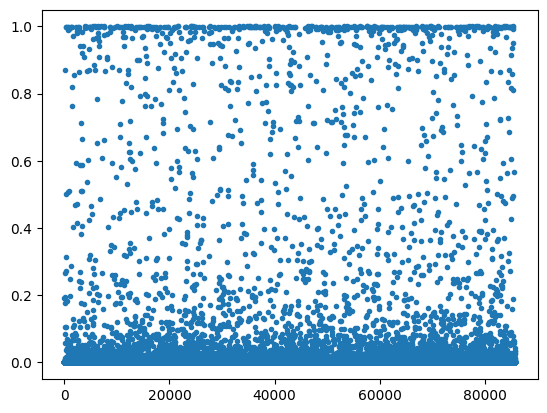

In [138]:
plt.plot(y_pred_test[:,0], '.')

In [ ]:
tn, fp, fn, tp = confusion_matrix([0, 1, 0, 1], [1, 1, 1, 0]).ravel().tolist()
(tn, fp, fn, tp)

In [140]:
print(np.unique(model.predict(X_test) == y_test, return_counts= True))

(array([False,  True]), array([  381, 85401]))


Optimal threshold: 0.0224


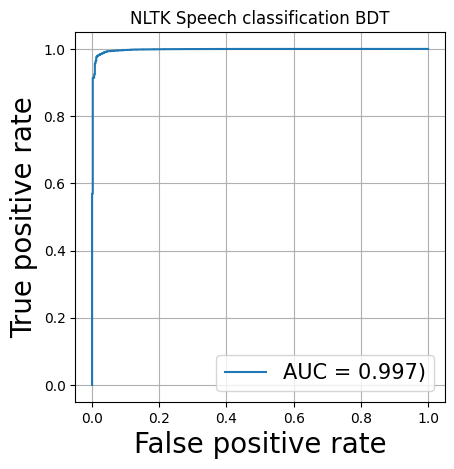

In [172]:
from sklearn.metrics import precision_recall_curve, roc_curve

# Get predicted probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Find threshold that maximizes F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_threshold = thresholds[np.argmax(f1_scores)]
auc = roc_auc_score(y_test, y_probs)
print(f"Optimal threshold: {best_threshold:.4f}")
disp = RocCurveDisplay.from_predictions(y_test, y_probs,  name="CNN", label = f'AUC = {auc:.3f})')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.ylabel('True positive rate', fontsize = 20)
plt.xlabel('False positive rate', fontsize = 20)
plt.legend(fontsize = 15)
plt.title('NLTK Speech classification BDT')
plt.grid()

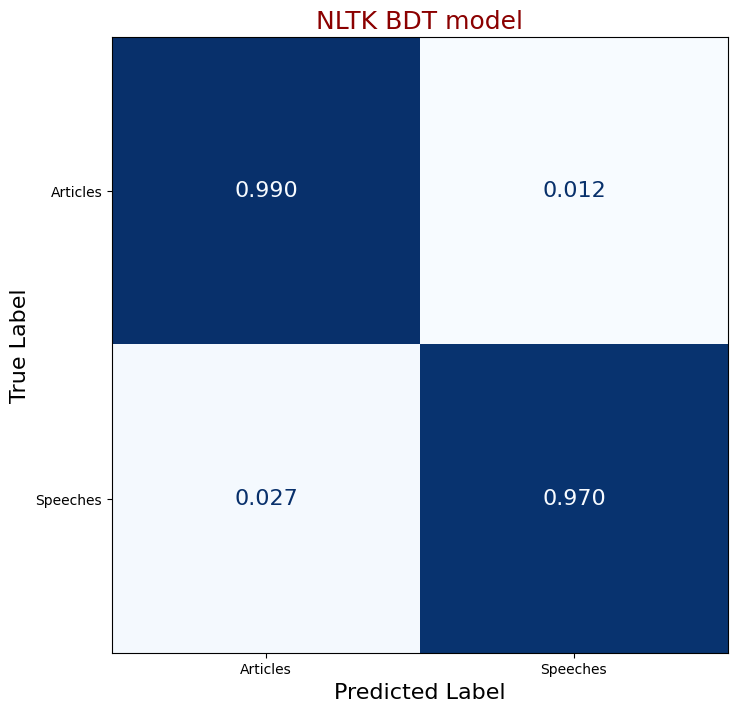

In [196]:
cm = confusion_matrix(y_test.values, y_probs > 1-best_threshold, normalize='true')
classes = ["Articles", "Speeches"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, xticks_rotation=0, cmap=plt.cm.Blues, colorbar=False)
for t in disp.text_.ravel():
    t.set_text(f"{float(t.get_text()):.3f}")
    t.set_fontsize(16)
plt.title("NLTK BDT model", fontsize=18, color="darkred")
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.savefig("confusion_matrix_speeches.png", dpi=300)
plt.show()

Best parameters found:  {'gamma': np.float64(0.6348732858009982), 'learning_rate': np.float64(0.28145626428614795), 'max_depth': 11, 'n_estimators': 218, 'reg_alpha': np.float64(0.9810189966210203), 'reg_lambda': np.float64(0.8275041888291987), 'subsample': np.float64(0.9341066351050259)}

<h1> Loading best model</h1>